In [1]:
# Telco Customer Churn datasetini indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)

print(dataset_path)

/kaggle/input/datasets/blastchar/telco-customer-churn


In [2]:
# Dataset dosyalarını kontrol ediyoruz

import os

print(os.listdir(dataset_path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
# Dataseti yüklüyoruz

import pandas as pd

df = pd.read_csv(dataset_path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Dataset bilgilerini kontrol ediyoruz

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# TotalCharges sütununu sayısala çeviriyoruz

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
# Eksik verileri temizliyoruz

df = df.dropna()

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Kategorik verileri sayısala çeviriyoruz

df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True


In [8]:
# Bağımlı ve bağımsız değişkenleri ayırıyoruz

X = df.drop("Churn_Yes", axis=1)

y = df["Churn_Yes"]

In [9]:
# Train test split yapıyoruz

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [10]:
# Verileri ölçeklendiriyoruz

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
# TensorFlow kütüphanelerini import ediyoruz

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

2026-05-18 11:56:46.341349: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779105406.586995      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779105406.656426      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779105407.246202      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779105407.246260      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779105407.246263      16 computation_placer.cc:177] computation placer alr

In [12]:
# ANN modelini oluşturuyoruz

ann = Sequential()

ann.add(Dense(64, activation="relu"))

ann.add(Dense(32, activation="relu"))

ann.add(Dense(1, activation="sigmoid"))

In [13]:
# Modeli derliyoruz

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

2026-05-18 11:57:12.292000: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
# Modeli eğitiyoruz

history = ann.fit(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6473 - loss: 0.6258 - val_accuracy: 0.7689 - val_loss: 0.4736
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9463 - loss: 0.1782 - val_accuracy: 0.7636 - val_loss: 0.4715
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9981 - loss: 0.0239 - val_accuracy: 0.7689 - val_loss: 0.4766
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 0.7653 - val_loss: 0.4824
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.7636 - val_loss: 0.4869
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 8.5175e-04 - val_accuracy: 0.7644 - val_loss: 0.4908
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 5.5130e-04 - val_accuracy: 0.7636 - val_loss: 0.4941
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 3.9756e-04 - val_

In [15]:
# Tahmin yapıyoruz

y_pred = ann.predict(X_test)

y_pred = (y_pred > 0.5)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [16]:
# Başarı skorlarını hesaplıyoruz

from sklearn.metrics import accuracy_score

ann_acc = accuracy_score(y_test, y_pred)

print("ANN Accuracy:", ann_acc)

ANN Accuracy: 0.7341862117981521


In [17]:
# Confusion matrix oluşturuyoruz

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[1033,    0],
       [ 374,    0]])

In [18]:
# Classification report oluşturuyoruz

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.73      1.00      0.85      1033
        True       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
# ANN modelini class_weight ile yeniden eğitiyoruz

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

ann = Sequential()

ann.add(Dense(32, activation="relu"))
ann.add(Dense(16, activation="relu"))
ann.add(Dense(1, activation="sigmoid"))

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = ann.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5784 - loss: 0.6783 - val_accuracy: 0.6427 - val_loss: 0.6119
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9126 - loss: 0.2724 - val_accuracy: 0.5938 - val_loss: 0.7355
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9879 - loss: 0.0542 - val_accuracy: 0.5689 - val_loss: 0.8127
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9979 - loss: 0.0147 - val_accuracy: 0.5724 - val_loss: 0.8441
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 0.5724 - val_loss: 0.8638
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.5707 - val_loss: 0.8878
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.5707 - val_loss: 0.9058
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.

In [20]:
# Yeni tahminleri alıyoruz

y_pred = ann.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

ann_acc = accuracy_score(y_test, y_pred)

print("ANN Accuracy:", ann_acc)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ANN Accuracy: 0.7448471926083866
[[764 269]
 [ 90 284]]
              precision    recall  f1-score   support

       False       0.89      0.74      0.81      1033
        True       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



In [21]:
# customerID varsa siliyoruz

if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

In [22]:
# Encoding işlemini yeniden yapıyoruz

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"].astype(int)

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
# Train test split işlemini yeniden yapıyoruz

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
# Verileri yeniden ölçeklendiriyoruz

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [26]:
# ANN modelini sıfırdan yeniden kuruyoruz

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential()

ann.add(Dense(32, activation="relu"))
ann.add(Dense(16, activation="relu"))
ann.add(Dense(1, activation="sigmoid"))

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
# ANN modelini yeniden eğitiyoruz

history = ann.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6680 - loss: 0.6068 - val_accuracy: 0.7440 - val_loss: 0.4846
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8736 - loss: 0.3371 - val_accuracy: 0.7529 - val_loss: 0.4714
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9731 - loss: 0.0996 - val_accuracy: 0.7484 - val_loss: 0.4818
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9928 - loss: 0.0321 - val_accuracy: 0.7440 - val_loss: 0.4960
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9978 - loss: 0.0135 - val_accuracy: 0.7440 - val_loss: 0.5054
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9998 - loss: 0.0056 - val_accuracy: 0.7369 - val_loss: 0.5118
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9997 - loss: 0.0033 - val_accuracy: 0.7378 - val_loss: 0.5148
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9998 - loss: 0.0023 - val_accuracy: 0.

In [28]:
# Model performansını ölçüyoruz

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

y_pred = ann.predict(X_test)

y_pred = (y_pred > 0.5)

ann_acc = accuracy_score(y_test, y_pred)

print("ANN Accuracy:", ann_acc)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ANN Accuracy: 0.7341862117981521
[[1033    0]
 [ 374    0]]
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1033
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


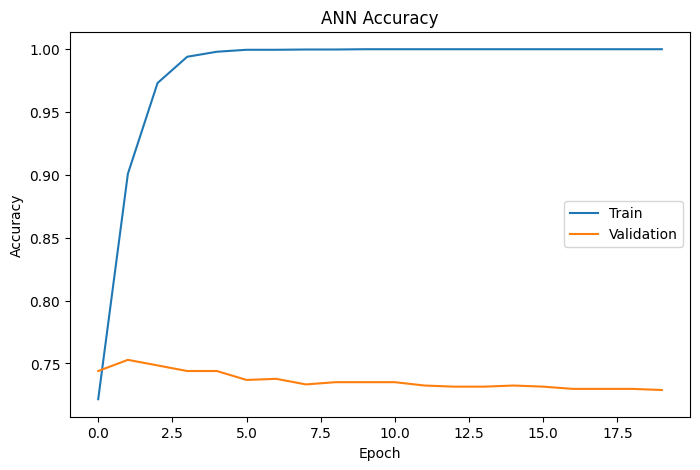

In [29]:
# Accuracy grafiğini çiziyoruz

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("ANN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

# Telco Customer Churn ANN Project Sonuçları

Bu projede Telco Customer Churn veri seti kullanılarak yapay sinir ağı (ANN) modeli geliştirilmiştir.

Proje kapsamında:

- Veri temizleme işlemleri yapılmıştır.
- Eksik veriler giderilmiştir.
- Kategorik veriler encoding işlemi ile sayısala dönüştürülmüştür.
- Veriler ölçeklendirilmiştir.
- Train/Test ayrımı yapılmıştır.
- TensorFlow ve Keras kullanılarak ANN modeli oluşturulmuştur.
- Model eğitilmiş ve performansı değerlendirilmiştir.

Model sonucunda:
- Accuracy skoru hesaplanmıştır.
- Confusion Matrix oluşturulmuştur.
- Classification Report incelenmiştir.
- Accuracy değişimi görselleştirilmiştir.

Bu proje ile:
- Deep Learning
- ANN
- TensorFlow
- Keras
- Classification
- Data Preprocessing

konuları uygulamalı olarak gerçekleştirilmiştir.